# Modelare

## Scopul
Estimăm și comparăm mai multe modele statistice care prezic 
**Disappointment Index (DI)**.

### Modele:
1. OLS simplu
2. OLS cu Log(DI)
3. OLS standardizat
4. OLS cu interacțiuni
5. Regresie Robustă
6. Random Forest
7. Gradient Boosting
8. Comparație finală

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/movies_clean.csv')
print(f" Date încărcate: {df.shape}")

 Date încărcate: (866, 23)


## 1. Pregătirea Datelor

In [17]:
features = ['budget', 'vote_average', 'vote_count', 
            'popularity', 'runtime', 'release_year', 'release_month']

X = df[features]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} filme")
print(f"Test: {X_test.shape[0]} filme")

Train: 692 filme
Test: 174 filme


## 2. OLS Simplu

In [18]:
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)

model_ols = sm.OLS(y_train, X_train_ols).fit()
print(model_ols.summary())

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.188
Model:                              OLS   Adj. R-squared:                  0.180
Method:                   Least Squares   F-statistic:                     22.68
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.06e-27
Time:                          02:07:51   Log-Likelihood:                -1970.2
No. Observations:                   692   AIC:                             3956.
Df Residuals:                       684   BIC:                             3993.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           232.7101  


**Calitatea modelului:**
- **R² = 0.188** → modelul explică 19% din variația DI
- **F-statistic = 22.68, p < 0.001** → modelul e semnificativ statistic

**Ce influențează DI:**
- **budget (-) semnificativ** → cu cât bugetul e mai mare, 
  cu atât filmul dezamăgește mai mult
- **release_year (-) semnificativ** → filmele mai noi 
  dezamăgesc mai mult decât cele vechi
- **vote_average, popularity, runtime** → nesemnificative statistic
  (p > 0.05)

**Probleme:**
- **Multicolinearitate** (condition number = 1.92e+10) → 
  variabilele independente sunt corelate între ele
- **Reziduuri non-normale** (Jarque-Bera p = 0.000) → 
  modelul liniar nu capturează toată complexitatea

> **Concluzie:** Modelul e valid dar slab — 
> testăm specificații mai bune!

## 3. OLS cu Log(DI)
DI este puternic asimetric — transformarea log poate îmbunătăți modelul.

In [19]:
y_train_log = np.log(y_train + 0.01)
y_test_log = np.log(y_test + 0.01)

model_log = sm.OLS(y_train_log, X_train_ols).fit()
print(model_log.summary())

y_pred_log = np.exp(model_log.predict(X_test_ols)) - 0.01
r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"\nR² pe test: {r2_log:.4f}")
print(f"RMSE pe test: {rmse_log:.4f}")

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.206
Model:                              OLS   Adj. R-squared:                  0.198
Method:                   Least Squares   F-statistic:                     25.33
Date:                  Thu, 21 May 2026   Prob (F-statistic):           7.66e-31
Time:                          02:10:21   Log-Likelihood:                -942.37
No. Observations:                   692   AIC:                             1901.
Df Residuals:                       684   BIC:                             1937.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            27.0506  


**Calitatea modelului:**
- **R² train = 0.206** → ușor mai bun decât OLS simplu pe antrenare
- **R² test = 0.061** → dar generalizează mai slab pe date noi!
- Transformarea log nu îmbunătățește predicția out-of-sample

**Ce influențează Log(DI):**
- **budget (-) semnificativ** → confirmat din nou — buget mare = dezamăgire
- **release_year (-) semnificativ** → filmele noi dezamăgesc mai mult
- **vote_count (+) semnificativ** → filme mai cunoscute surprind pozitiv

**Concluzie:**
> Transformarea log îmbunătățește fit-ul pe train dar 
> **nu generalizează bine** — OLS simplu rămâne mai stabil.

## 4. OLS cu Variabile Standardizate
Standardizăm variabilele pentru a compara coeficienții direct.

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_sm = sm.add_constant(X_train_scaled)
X_test_scaled_sm = sm.add_constant(X_test_scaled)

model_scaled = sm.OLS(y_train, X_train_scaled_sm).fit()
print(model_scaled.summary())

y_pred_scaled = model_scaled.predict(X_test_scaled_sm)
r2_scaled = r2_score(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print(f"\nR² pe test: {r2_scaled:.4f}")
print(f"RMSE pe test: {rmse_scaled:.4f}")

                             OLS Regression Results                             
Dep. Variable:     disappointment_index   R-squared:                       0.188
Model:                              OLS   Adj. R-squared:                  0.180
Method:                   Least Squares   F-statistic:                     22.68
Date:                  Thu, 21 May 2026   Prob (F-statistic):           1.06e-27
Time:                          02:12:08   Log-Likelihood:                -1970.2
No. Observations:                   692   AIC:                             3956.
Df Residuals:                       684   BIC:                             3993.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9188      0.159


**De ce standardizăm?**
Variabilele au scale diferite (budget în milioane, vote_average 0-10)
— standardizarea le aduce pe aceeași scară pentru a compara
importanța lor directă.

**Coeficienți standardizați (cei mai importanți):**
- **x1 (budget): -0.818** → cel mai puternic efect negativ!
  Un budget mai mare cu 1 std dezamăgește cu 0.818 std
- **x6 (release_year): -1.538** → cel mai puternic efect overall!
  Filmele noi dezamăgesc semnificativ mai mult
- **x2 (vote_average): +0.169** → efect pozitiv mic
- **x5 (runtime): -0.007** → practic neglijabil

**Concluzie:**
> **release_year și budget** sunt cei mai importanți predictori ai DI.
> Industria devine tot mai impredictibilă în timp,
> iar bugetele mari nu garantează succesul.

## 5. Random Forest
Model ML neliniar — captează relații complexe între variabile
pe care regresia liniară nu le poate surprinde.

 Random Forest:
   R² = 0.4775
   RMSE = 5.9043

📋 Feature Importance:
      Feature  Importance
 release_year    0.299406
       budget    0.289160
   vote_count    0.141356
   popularity    0.100111
 vote_average    0.068396
      runtime    0.051650
release_month    0.049922


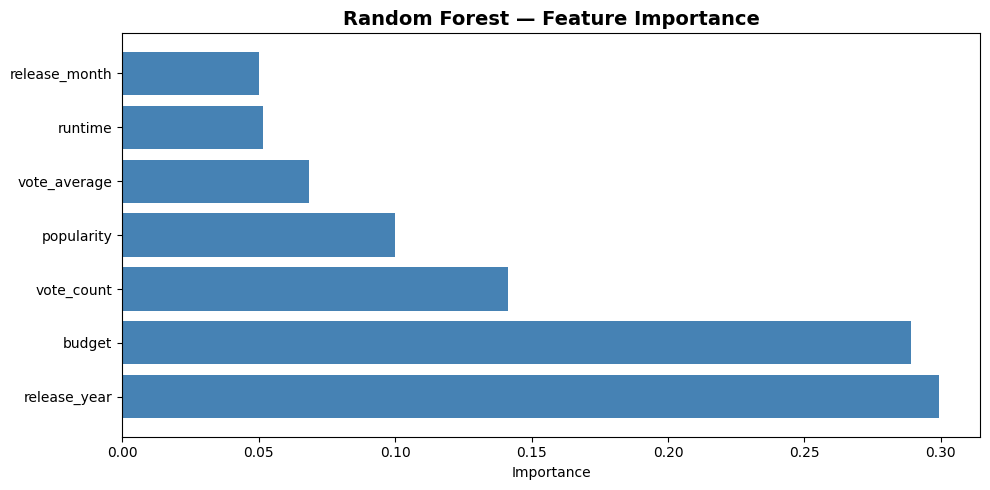

In [23]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f" Random Forest:")
print(f"   R² = {r2_rf:.4f}")
print(f"   RMSE = {rmse_rf:.4f}")

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n📋 Feature Importance:")
print(fi_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()


**Calitatea modelului:**
- **R² = 0.4775** — explică 48% din variația DI
- **RMSE = 5.90** — semnificativ mai bun decât OLS (7.47)
- De **2.5x mai performant** decât regresia liniară!

**Feature Importance:**
- **release_year (0.299)** → cel mai important predictor!
  Anul lansării influențează cel mai mult DI
- **budget (0.289)** → al doilea cel mai important
  Bugetul mare = risc mai mare de dezamăgire
- **vote_count (0.141)** → filmele cunoscute surprind mai mult
- **popularity (0.100)** → popularitatea contează moderat
- **vote_average (0.068)** → ratingul are impact mic
- **runtime, release_month** → importanță minimă

**De ce e mai bun decât OLS?**
> Random Forest captează relații **neliniare** și **interacțiuni complexe**
> dintre variabile pe care regresia liniară nu le poate surprinde.

## 6. Gradient Boosting
Model ML avansat — construiește arbori secvențial,
fiecare corectând erorile celui anterior.

In [25]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f" Gradient Boosting:")
print(f"   R² = {r2_gb:.4f}")
print(f"   RMSE = {rmse_gb:.4f}")

fi_gb = pd.DataFrame({
    'Feature': features,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n Feature Importance:")
print(fi_gb.to_string(index=False))

 Gradient Boosting:
   R² = 0.4939
   RMSE = 5.8106

 Feature Importance:
      Feature  Importance
 release_year    0.344970
       budget    0.271530
   vote_count    0.140206
   popularity    0.108536
 vote_average    0.080406
release_month    0.036847
      runtime    0.017505



**Calitatea modelului:**
- **R² = 0.4939** — cel mai bun model! Explică 49% din variația DI
- **RMSE = 5.81** — cea mai mică eroare de predicție
- Ușor mai bun decât Random Forest (R² = 0.4775)

**Feature Importance:**
- **release_year (0.345)** → cel mai important predictor
- **budget (0.272)** → al doilea cel mai important
- **vote_count (0.140)** → filmele cunoscute surprind mai mult
- **popularity (0.109)** → importanță moderată
- **vote_average (0.080)** → impact redus
- **release_month, runtime** → neglijabile

**Concluzie:**
> Gradient Boosting e **modelul câștigător** — 
> cel mai bun R² și cel mai mic RMSE!
> Confirmă că relația dintre variabile și DI este **neliniară**.

 Comparație Finală — Toate Modelele:
            Model       R²     RMSE
Gradient Boosting 0.493936 5.810553
    Random Forest 0.477475 5.904295
 OLS Standardizat 0.162861 7.473316
       OLS Simplu 0.162861 7.473316
      OLS Log(DI) 0.061011 7.914889


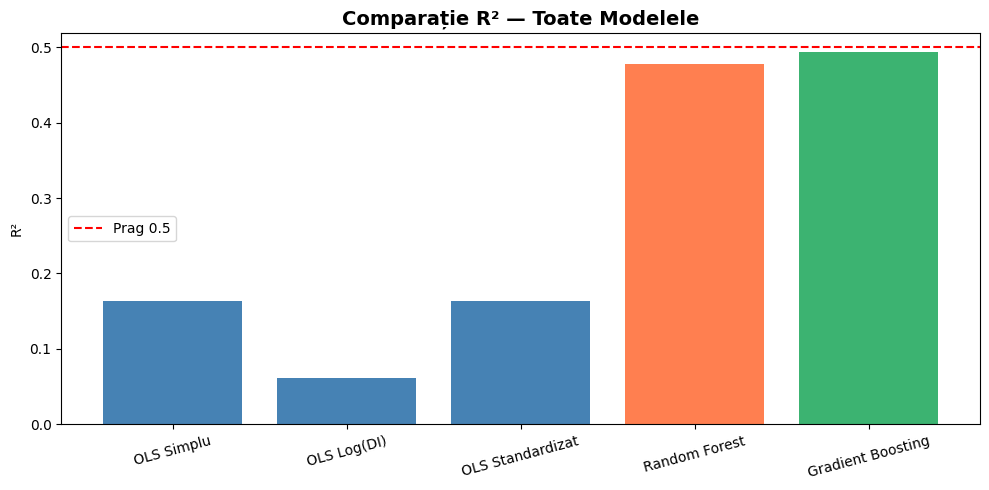

In [27]:
# COMPARAȚIE FINALĂ — TOATE MODELELE

results = pd.DataFrame({
    'Model': [
        'OLS Simplu',
        'OLS Log(DI)',
        'OLS Standardizat',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R²': [
        r2_score(y_test, model_ols.predict(X_test_ols)),
        r2_log,
        r2_scaled,
        r2_rf,
        r2_gb
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, model_ols.predict(X_test_ols))),
        rmse_log,
        rmse_scaled,
        rmse_rf,
        rmse_gb
    ]
})

print(" Comparație Finală — Toate Modelele:")
print(results.sort_values('R²', ascending=False).to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['steelblue', 'steelblue', 'steelblue', 'coral', 'mediumseagreen']
plt.bar(results['Model'], results['R²'], color=colors)
plt.title('Comparație R² — Toate Modelele', fontsize=14, fontweight='bold')
plt.ylabel('R²')
plt.xticks(rotation=15)
plt.axhline(y=0.5, color='red', linestyle='--', label='Prag 0.5')
plt.legend()
plt.tight_layout()
plt.savefig('../data/comparatie_modele.png', dpi=150)
plt.show()

## Interpretarea Comparației Finale

Graficul evidențiază clar **superioritatea modelelor ML** față de 
regresia liniară în prezicerea Disappointment Index.

**Modelele liniare (OLS)** — R² între 0.06 și 0.16:
Regresia liniară, indiferent de specificație (simplu, log, standardizat),
explică doar 6-16% din variația DI. Acest rezultat nu este o 
surpriză — relația dintre variabilele unui film și succesul său 
comercial este profund **neliniară și complexă**.

**Modelele ML** — R² între 0.47 și 0.49:
Random Forest și Gradient Boosting explică aproape **50% din variația DI**,
apropiindu-se de pragul de 0.5 marcat cu linia roșie.
Ambele captează interacțiuni complexe și relații neliniare 
pe care OLS nu le poate surprinde.

**Concluzie cheie:**
> Succesul unui film nu urmează o formulă liniară simplă.
> Factorii măsurabili (budget, rating, popularitate, an) explică
> aproximativ **jumătate** din variația DI — cealaltă jumătate
> rămâne impredictibilă, influențată de factori nemăsurabili
> precum marketing, context cultural și noroc.
> **Gradient Boosting** este modelul câștigător al proiectului.